# load modules

In [1]:
!pip install optuna

In [2]:
# =========================
# System & File Management
# =========================
import os
import re
import time
import json
import copy
import pickle
from pathlib import Path
import warnings

# =========================
# Data Handling & Numerical
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# =========================
# Statistics
# =========================
from scipy.stats import chi2_contingency, mannwhitneyu

# =========================
# Machine Learning - Preprocessing
# =========================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import log_loss

# =========================
# Machine Learning - Modeling & Evaluation
# =========================
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# =========================
# Optimization
# =========================
import optuna
from optuna.pruners import HyperbandPruner  # or MedianPruner
from optuna.samplers import TPESampler

# =========================
# XGBoost
# =========================
# from xgboost import XGBClassifier
import xgboost as xgb

# =========================
# Deep Learning (PyTorch)
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Dimensionality Reduction & Clustering
# =========================
import umap
import hdbscan

# =========================
# Utilities
# =========================
from tqdm import tqdm
import joblib

# =========================
# Warnings Configuration
# =========================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.impute')
os.environ['PYTHONWARNINGS'] = 'ignore'


In [3]:
from itertools import combinations

# Functions

In [4]:
# 设置随机种子保证可复现性
torch.manual_seed(42)
np.random.seed(42)

In [5]:
def filter_data_by_clusters(X, y, cluster_df, clusters_to_include):
    keep_ids = cluster_df.loc[
        cluster_df["cluster"].isin(clusters_to_include),
        "sample_id"
    ]
    print(f"组合 {clusters_to_include} 原始 keep_ids 数量: {len(keep_ids)}")

    keep_ids = pd.Index(keep_ids).intersection(X.index)
    print(f"与 X.index 交集后数量: {len(keep_ids)}")

    X_sub = X.loc[keep_ids].copy()
    y_sub = y.loc[keep_ids].copy()
    return X_sub, y_sub

def evaluate_model_on_test_set_with_shap(
    X_test,
    y_test,
    model_path,
    n_bootstrap=1000,
    output_dir='./boots_output',
    output_csv_name='test_results.csv',
    random_seed=42
):
    """
    使用已训练好的 XGBoost 模型在测试集上评估，并进行 bootstrap + SHAP 分析，同时计算 p-value。

    参数:
        X_test (pd.DataFrame): 测试集特征
        y_test (pd.Series / np.array): 测试集标签
        model_path (str): XGBoost 模型路径
        n_bootstrap (int): bootstrap 重采样次数
        output_dir (str): 输出目录
        output_csv_name (str): bootstrap 结果 CSV 文件名
        random_seed (int): 随机种子

    返回:
        dict: 包含指标、置信区间、bootstrap 数据、p-values
    """
    import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
    import shap, xgboost as xgb
    from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

    os.makedirs(output_dir, exist_ok=True)

    # ------------------- 1️⃣ 加载模型 -------------------
    model = xgb.Booster()
    model.load_model(model_path)
    dtest = xgb.DMatrix(X_test)
    test_preds_proba = model.predict(dtest)

    # ------------------- 2️⃣ 计算指标 -------------------
    test_auc = roc_auc_score(y_test, test_preds_proba)
    test_auprc = average_precision_score(y_test, test_preds_proba)
    test_logloss = log_loss(y_test, test_preds_proba)

    # ------------------- 3️⃣ Bootstrap -------------------
    rng = np.random.default_rng(seed=random_seed)
    aucs, auprcs, loglosses = [], [], []

    for _ in range(n_bootstrap):
        indices = rng.choice(len(y_test), size=len(y_test), replace=True)
        y_true_boot = y_test.iloc[indices] if isinstance(y_test, pd.Series) else y_test[indices]
        y_pred_boot = test_preds_proba[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
        loglosses.append(log_loss(y_true_boot, y_pred_boot))

    aucs = np.array(aucs)
    auprcs = np.array(auprcs)
    loglosses = np.array(loglosses)

    auc_ci = np.percentile(aucs, [2.5, 97.5])
    auprc_ci = np.percentile(auprcs, [2.5, 97.5])
    logloss_ci = np.percentile(loglosses, [2.5, 97.5])

    # ------------------- 3️⃣ p-value 计算 -------------------
    # baseline
    baseline_auc = 0.5
    baseline_auprc = y_test.mean()  # random guess AUPRC
    baseline_logloss = log_loss(y_test, np.full_like(y_test, baseline_auprc))

    pval_auc = np.mean(aucs <= baseline_auc)
    pval_auprc = np.mean(auprcs <= baseline_auprc)
    pval_logloss = np.mean(loglosses >= baseline_logloss)  # lower is better

    print(f"AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f}-{auc_ci[1]:.4f}), p={pval_auc:.4f}")
    print(f"AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f}-{auprc_ci[1]:.4f}), p={pval_auprc:.4f}")
    print(f"LogLoss: {test_logloss:.4f} (95% CI: {logloss_ci[0]:.4f}-{logloss_ci[1]:.4f}), p={pval_logloss:.4f}")

    # ------------------- 4️⃣ 保存 bootstrap 数据 & 图 -------------------
    bootstrap_df = pd.DataFrame({'auc': aucs, 'auprc': auprcs, 'logloss': loglosses})
    csv_path = os.path.join(output_dir, output_csv_name)
    bootstrap_df.to_csv(csv_path, index=False)

    # 画箱线图
    bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')
    plt.figure(figsize=(8,6))
    sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
    plt.title(f'Bootstrap Metrics (n={len(y_test)})')
    plt.tight_layout()
    plt.savefig(csv_path.replace('.csv', '.png'))
    plt.close()

    # ------------------- 5️⃣ SHAP 分析 -------------------
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)
    shap_csv_path = csv_path.replace('.csv', '_shap.csv')
    shap_df.to_csv(shap_csv_path)

    shap.summary_plot(shap_values, X_test, show=False)
    shap_png_path = csv_path.replace('.csv', '_shap.png')
    plt.savefig(shap_png_path)
    plt.close()

    # ------------------- 6️⃣ 返回结果 -------------------
    return {
        "auc": test_auc, "auc_ci": auc_ci, "auc_pval": pval_auc,
        "auprc": test_auprc, "auprc_ci": auprc_ci, "auprc_pval": pval_auprc,
        "logloss": test_logloss, "logloss_ci": logloss_ci, "logloss_pval": pval_logloss,
        "bootstrap_df": bootstrap_df,
        "shap_values": shap_df
    }




def retrain_and_evaluate_all_cluster_combinations(
    cluster_csv_path,
    X_train, y_train,
    X_test, y_test,
    clusters_to_include,
    min_comb_size=1,
    max_comb_size=2,
    n_bootstrap=1000,
    output_dir="./cluster_retrain_results",
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)

    # ================== 1️⃣ 读 CSV 并统一列名 ==================
    cluster_df = pd.read_csv(cluster_csv_path)
    cluster_df = cluster_df.rename(columns={
        "sample_index": "sample_id",
        "cluster_id": "cluster"
    })
    cluster_df["sample_id"] = cluster_df["sample_id"].astype(str)

    # 保证 index 类型一致
    X_train.index = X_train.index.astype(str)
    X_test.index = X_test.index.astype(str)
    y_train.index = y_train.index.astype(str)
    y_test.index = y_test.index.astype(str)

    # ================== 2️⃣ 枚举 cluster 组合 ==================
    all_combs = []
    for k in range(min_comb_size, max_comb_size + 1):
        all_combs.extend(list(combinations(clusters_to_include, k)))

    results_summary = []
    skipped_records = []

    for comb in tqdm(all_combs, desc="Cluster combinations"):
        comb_name = "_".join(map(str, comb))
        print(f"\n🚀 Cluster 组合重新训练: {comb_name}")

        try:
            # ================== 3️⃣ 按 cluster & set 筛选 train / val ==================
            X_tr, y_tr = filter_data_by_clusters(
                X_train, y_train,
                cluster_df[cluster_df["set"]=="train"],
                comb
            )
            X_te, y_te = filter_data_by_clusters(
                X_test, y_test,
                cluster_df[cluster_df["set"]=="val"],
                comb
            )

            # QC：样本量 & 正样本
            if len(y_tr) < 50:
                raise ValueError("训练样本过少")
            if y_tr.sum() == 0 or y_te.sum() == 0:
                raise ValueError("无正样本")

            # ================== 4️⃣ train / internal val split ==================
            X_subtr, X_val, y_subtr, y_val = train_test_split(
                X_tr, y_tr,
                test_size=0.2,
                stratify=y_tr,
                random_state=random_seed
            )

            # ================== 5️⃣ 重新训练模型 ==================
            eval_results = run_single_train_val(
                X_train=X_subtr,
                y_train=y_subtr,
                X_val=X_val,
                y_val=y_val,
                feature_names=X_tr.columns.tolist(),
                hospital_id=f"19_cluster_{comb_name}",
                random_state=random_seed
            )

            # ================== 6️⃣ test set bootstrap 评估 ==================
            test_result = evaluate_model_on_test_set_with_shap(
                X_test=X_te,
                y_test=y_te,
                model_path=eval_results["final_model_path"],
                n_bootstrap=1000,
                output_dir="./cluster_retrain_results",
                output_csv_name=f"cluster_{comb_name}_test.csv"
            )

            # ================== 7️⃣ 保存结果 ==================
            results_summary.append({
                "combination": comb_name,
                "num_train": len(y_tr),
                "num_test": len(y_te),
                "positive_rate_test": y_te.mean(),
                "auc": test_result["auc"],
                "auc_ci_lower": test_result["auc_ci"][0],
                "auc_ci_upper": test_result["auc_ci"][1],
                "auc_pval": test_result["auc_pval"],         # <-- added
                "auprc": test_result["auprc"],
                "auprc_ci_lower": test_result["auprc_ci"][0],
                "auprc_ci_upper": test_result["auprc_ci"][1],
                "auprc_pval": test_result["auprc_pval"],     # <-- added
                "logloss": test_result["logloss"],
                "logloss_ci_lower": test_result["logloss_ci"][0],
                "logloss_ci_upper": test_result["logloss_ci"][1],
                "logloss_pval": test_result["logloss_pval"]  # <-- added
            })


        except Exception as e:
            print(f"❌ Cluster {comb_name} 失败: {e}")
            skipped_records.append({
                "combination": comb_name,
                "error": str(e)
            })

    # ================== 8️⃣ 保存汇总结果 ==================
    pd.DataFrame(results_summary).to_csv(
        os.path.join(output_dir, "summary_cluster_retrained_models.csv"),
        index=False
    )
    pd.DataFrame(skipped_records).to_csv(
        os.path.join(output_dir, "skipped_cluster_retrained_models.csv"),
        index=False
    )

    print(f"\n✅ 所有 cluster 组合重新训练完成，结果已保存至 {output_dir}")

In [157]:

def evaluate_model_with_bootstrap(
    cluster_csv_path,
    X_target_test,
    y_target_test,
    model_path,
    clusters_to_include=[1, 2, 3],
    n_bootstrap=1000,
    output_dir='/content/boots_output',
    output_csv_name='all-test-1.csv',
    random_seed=42
):
    df_2 = pd.read_csv(cluster_csv_path)
    index_to_cluster = df_2.set_index("sample_index")["cluster_id"]
    X_target_test["cluster_id"] = X_target_test.index.map(index_to_cluster)
    null_count = X_target_test['cluster_id'].isnull().sum()
    print(f"缺失的 cluster_id 数量: {null_count}")

    mask = X_target_test['cluster_id'].isin(clusters_to_include)
    X_target_test_sub = X_target_test[mask]
    y_target_test_sub = y_target_test[mask.values]
    num_samples = len(X_target_test_sub)
    pos_rate = y_target_test_sub.mean() * 100
    print(f"➡️ 组合 {clusters_to_include}：样本数 {num_samples}, Positive Rate: {pos_rate:.2f}%")

    if len(np.unique(y_target_test_sub)) < 2:
        label_val = y_target_test_sub[0]
        print(f"⚠️ 该组合仅包含一个类别 (label={label_val})，跳过评估")
        return None

    X_target_test_sub = X_target_test_sub.drop(columns=['cluster_id'])

    model = xgb.Booster()
    model.load_model(model_path)
    dtest = xgb.DMatrix(X_target_test_sub)
    test_preds_proba = model.predict(dtest)

    test_auc = roc_auc_score(y_target_test_sub, test_preds_proba)
    test_auprc = average_precision_score(y_target_test_sub, test_preds_proba)
    test_logloss = log_loss(y_target_test_sub, test_preds_proba)

    print(f"🎯 测试集 AUC: {test_auc:.4f}")
    print(f"🎯 测试集 AUPRC: {test_auprc:.4f}")
    print(f"🎯 测试集 LogLoss: {test_logloss:.4f}")

    rng = np.random.default_rng(seed=random_seed)
    aucs, auprcs, loglosses = [], [], []
    for _ in range(n_bootstrap):
        indices = rng.choice(len(y_target_test_sub), size=len(y_target_test_sub), replace=True)
        y_true_boot = y_target_test_sub[indices]
        y_pred_boot = test_preds_proba[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
        loglosses.append(log_loss(y_true_boot, y_pred_boot))

    auc_ci = np.percentile(aucs, [2.5, 97.5])
    auprc_ci = np.percentile(auprcs, [2.5, 97.5])
    logloss_ci = np.percentile(loglosses, [2.5, 97.5])

    # ================== p-value 计算 ==================
    baseline_auc = 0.5
    baseline_auprc = y_target_test_sub.mean()
    baseline_logloss = log_loss(
        y_target_test_sub,
        np.full_like(y_target_test_sub, baseline_auprc, dtype=float)
    )

    pval_auc = np.mean(np.array(aucs) <= baseline_auc)
    pval_auprc = np.mean(np.array(auprcs) <= baseline_auprc)
    pval_logloss = np.mean(np.array(loglosses) >= baseline_logloss)


    print(f"✅ 测试集 AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
    print(f"✅ 测试集 AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
    print(f"✅ 测试集 LogLoss: {test_logloss:.4f} (95% CI: {logloss_ci[0]:.4f} - {logloss_ci[1]:.4f})")

    os.makedirs(output_dir, exist_ok=True)

    # 保存 bootstrap 数据
    bootstrap_df = pd.DataFrame({'auc': aucs, 'auprc': auprcs, 'logloss': loglosses})
    csv_path = os.path.join(output_dir, output_csv_name)
    bootstrap_df.to_csv(csv_path, index=False)

    # 画图
    bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
    plt.title(f'Bootstrap Metrics (n={num_samples}, pos={pos_rate:.1f}%)')
    plt.tight_layout()
    png_path = csv_path.replace('.csv', '.png')
    plt.savefig(png_path)
    plt.close()

    # SHAP 值
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_target_test_sub)
    shap_df = pd.DataFrame(shap_values, columns=X_target_test_sub.columns, index=X_target_test_sub.index)
    shap_csv_path = csv_path.replace('.csv', '_shap.csv')
    shap_df.to_csv(shap_csv_path)

    shap.summary_plot(shap_values, X_target_test_sub, show=False)
    shap_png_path = csv_path.replace('.csv', '_shap.png')
    plt.savefig(shap_png_path)
    plt.close()

    return {
        "auc": test_auc, "auc_ci": auc_ci, "auc_pval": pval_auc,
        "auprc": test_auprc, "auprc_ci": auprc_ci, "auprc_pval": pval_auprc,
        "logloss": test_logloss, "logloss_ci": logloss_ci, "logloss_pval": pval_logloss,
        "bootstrap_df": bootstrap_df,
        "num_samples": num_samples,
        "positive_rate": pos_rate
    }

def evaluate_all_cluster_combinations(
    cluster_csv_path,
    X_target_test,
    y_target_test,
    model_path,
    clusters_to_include,
    min_comb_size=1,
    max_comb_size=2,
    n_bootstrap=1000,
    output_dir='./results',
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)
    all_combs = []
    for k in range(min_comb_size, max_comb_size + 1):
        all_combs.extend(list(combinations(clusters_to_include, k)))

    results_summary = []
    skipped_records = []

    for comb in tqdm(all_combs):
        comb_name = "_".join(map(str, comb))
        output_csv = f"cluster_{comb_name}_results.csv"
        try:
            result = evaluate_model_with_bootstrap(
                cluster_csv_path=cluster_csv_path,
                X_target_test=X_target_test.copy(),
                y_target_test=y_target_test.copy(),
                model_path=model_path,
                clusters_to_include=list(comb),
                n_bootstrap=n_bootstrap,
                output_dir=output_dir,
                output_csv_name=output_csv,
                random_seed=random_seed
            )
            if result is not None:
                results_summary.append({
                    "combination": comb_name,
                    "num_samples": result["num_samples"],
                    "positive_rate": result["positive_rate"],

                    "auc": result["auc"],
                    "auc_ci_lower": result["auc_ci"][0],
                    "auc_ci_upper": result["auc_ci"][1],
                    "auc_pval": result["auc_pval"],

                    "auprc": result["auprc"],
                    "auprc_ci_lower": result["auprc_ci"][0],
                    "auprc_ci_upper": result["auprc_ci"][1],
                    "auprc_pval": result["auprc_pval"],

                    "logloss": result["logloss"],
                    "logloss_ci_lower": result["logloss_ci"][0],
                    "logloss_ci_upper": result["logloss_ci"][1],
                    "logloss_pval": result["logloss_pval"]
                })

        except Exception as e:
            print(f"❌ 组合 {comb_name} 报错: {e}")
            skipped_records.append({"combination": comb_name, "error": str(e)})

    summary_df = pd.DataFrame(results_summary)
    summary_path = os.path.join(output_dir, "summary_results.csv")
    summary_df.to_csv(summary_path, index=False)

    skipped_path = os.path.join(output_dir, "skipped_combinations.csv")
    pd.DataFrame(skipped_records).to_csv(skipped_path, index=False)
    print(f"✅ 所有评估完成。结果保存在 {output_dir}")



def bootstrap_metrics(y_true, y_pred_prob, y_pred, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(seed=42)
    metrics_boot = {
        'auprc': [],
        'auroc': [],
        'logloss': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        yt = y_true[idx]
        yp_prob = y_pred_prob[idx]
        yp = y_pred[idx]
        # 跳过如果某个bootstrap样本只包含单一类别（会报错）
        if len(np.unique(yt)) < 2:
            continue
        metrics_boot['auprc'].append(average_precision_score(yt, yp_prob))
        metrics_boot['auroc'].append(roc_auc_score(yt, yp_prob))
        metrics_boot['logloss'].append(log_loss(yt, yp_prob))
        metrics_boot['accuracy'].append(accuracy_score(yt, yp))
        metrics_boot['precision'].append(precision_score(yt, yp, zero_division=0))
        metrics_boot['recall'].append(recall_score(yt, yp, zero_division=0))
        metrics_boot['f1'].append(f1_score(yt, yp, zero_division=0))

    # 计算均值和95%置信区间
    summary = {}
    for k, vals in metrics_boot.items():
        vals = np.array(vals)
        mean = np.mean(vals)
        lower = np.percentile(vals, 2.5)
        upper = np.percentile(vals, 97.5)
        summary[k] = (mean, lower, upper)
    return summary


def run_single_train_val(X_train, y_train, X_val, y_val, model_name='xgboost',
                         feature_names=None, num_clusters=5, tune_params=False,
                         n_trials=20, hospital_id=None, random_state=42):
    """
    用xgboost原生API训练+early stopping，bootstrap评估，保存模型。
    最后将 train + val 合并进行最终训练并保存。
    包含：
      - 自动计算 scale_pos_weight 以稳定 AUPRC
      - bootstrap CI 计算
      - 可选简单调参 (max_depth, learning_rate)
    """
    save_folder = f'saved_models_{model_name}_single'
    os.makedirs(save_folder, exist_ok=True)

    print(f"【{model_name.upper()}】单次训练验证开始 - {time.strftime('%Y-%m-%d %H:%M:%S')}")
    model_filename = f'best_{model_name}_{hospital_id}.model' if hospital_id else f'best_{model_name}.model'
    model_path = os.path.join(save_folder, model_filename)
    print(f"✅ 模型输出路径: {model_path}")

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # 自动计算正负样本比例
    pos = np.sum(y_train)
    neg = len(y_train) - pos
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    params = {
        'objective': 'binary:logistic',
        'eval_metric': ['aucpr', 'logloss'],  # 同时监控 AUPRC 和 logloss
        'learning_rate': 0.01,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': random_state,
        'nthread': 1,
        'verbosity': 0,
        'scale_pos_weight': scale_pos_weight
    }

    # 可选简单调参
    if tune_params:
        best_score = -1
        best_params = params.copy()
        for depth, lr in itertools.product([4, 6, 8], [0.01, 0.05, 0.1]):
            tmp_params = params.copy()
            tmp_params.update({'max_depth': depth, 'learning_rate': lr})
            bst_tmp = xgb.train(tmp_params, dtrain, num_boost_round=100,
                                evals=[(dval, 'eval')], verbose_eval=False)
            preds = bst_tmp.predict(dval)
            score = average_precision_score(y_val, preds)
            if score > best_score:
                best_score = score
                best_params.update({'max_depth': depth, 'learning_rate': lr})
        params = best_params
        print(f"🔧 调参完成 | 最佳 max_depth={params['max_depth']}, learning_rate={params['learning_rate']}")

    print(f"\n🏗️ 训练{model_name}模型中...")
    start_time = time.time()

    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'eval')],
        early_stopping_rounds=10,
        verbose_eval=20
    )

    train_time = time.time() - start_time
    print(f"✅ 训练完成 | 耗时: {train_time:.1f}s")

    print("\n📊 模型评估中...")
    val_preds = bst.predict(dval)

    auroc = roc_auc_score(y_val, val_preds)
    auprc = average_precision_score(y_val, val_preds)
    accuracy = accuracy_score(y_val, val_preds > 0.5)

    # Bootstrap评估
    n_bootstrap = 1000
    auroc_samples = []
    auprc_samples = []

    for _ in tqdm(range(n_bootstrap), desc="Bootstrap评估"):
        idx = resample(np.arange(len(y_val)), stratify=y_val)
        auroc_samples.append(roc_auc_score(y_val[idx], val_preds[idx]))
        auprc_samples.append(average_precision_score(y_val[idx], val_preds[idx]))

    auroc_ci = np.percentile(auroc_samples, [2.5, 97.5])
    auprc_ci = np.percentile(auprc_samples, [2.5, 97.5])

    # 保存验证模型
    bst.save_model(model_path)

    # 提取特征重要性
    feature_importances = {}
    if feature_names is not None:
        fmap = {f'f{i}': name for i, name in enumerate(feature_names)}
        score = bst.get_score(importance_type='weight')
        for k, v in score.items():
            feature_importances[fmap.get(k, k)] = v

    eval_results = {
        'metrics': {
            'auroc': auroc,
            'auroc_ci': list(auroc_ci),
            'auprc': auprc,
            'auprc_ci': list(auprc_ci),
            'accuracy': accuracy,
            'train_time_s': train_time
        },
        'model_path': model_path,
        'feature_importances': feature_importances
    }

    print("\n🎯 最终评估结果:")
    print(f"AUROC: {auroc:.4f} (95% CI: {auroc_ci[0]:.4f} - {auroc_ci[1]:.4f})")
    print(f"AUPRC: {auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
    print(f"Accuracy: {accuracy:.4f}")

    # ============ 🔁 retrain on full train+val ==============
    print("\n🔁 使用 train + val 合并数据进行最终训练...")
    dfull = xgb.DMatrix(np.concatenate([X_train, X_val]), label=np.concatenate([y_train, y_val]))

    bst_final = xgb.train(
        params=params,
        dtrain=dfull,
        num_boost_round=bst.best_iteration + 1
    )

    final_model_path = model_path.replace('.model', '_final.model')
    bst_final.save_model(final_model_path)

    print(f"✅ 最终模型已保存: {final_model_path}")
    eval_results['final_model_path'] = final_model_path

    return eval_results


def plot_and_metrics(embedding, cluster_labels, y, X, X_index, model, save_folder, prefix):
    reduced_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'], index=X_index)
    reduced_df['cluster'] = cluster_labels
    reduced_df['true'] = y.values

    # 可视化：UMAP + HDBSCAN
    plt.figure(figsize=(10, 8))
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters[unique_clusters >= 0])
    palette = sns.color_palette('tab10', n_clusters if n_clusters > 0 else 1)

    sns.scatterplot(
        data=reduced_df,
        x='UMAP1',
        y='UMAP2',
        hue='cluster',
        palette=palette,
        alpha=0.7,
        legend='full',
        hue_order=[c for c in sorted(unique_clusters) if c >= 0]
    )
    plt.title(f'UMAP + HDBSCAN Clustering on SHAP values ({prefix} set)')
    plt.savefig(os.path.join(save_folder, f'umap_hdbscan_clusters_{prefix}.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # 可视化：每簇正类率柱状图
    plt.figure(figsize=(8, 5))
    sns.barplot(data=reduced_df[reduced_df['cluster'] >= 0], x='cluster', y='true', estimator=np.mean, ci=None)
    plt.ylabel('True label positive rate')
    plt.title(f'True label distribution per cluster ({prefix} set)')
    plt.savefig(os.path.join(save_folder, f'cluster_true_distribution_{prefix}.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # 模型预测 & 聚类内指标
    print(f"计算 {prefix} 集合的各簇指标...")
    y_pred = model.predict(X)
    if hasattr(y_pred, 'shape') and len(y_pred.shape) == 2:
        y_pred = (y_pred[:, 1] if y_pred.shape[1] > 1 else y_pred[:, 0]) > 0.5
        y_pred = y_pred.astype(int)

    non_noise_mask = cluster_labels != -1
    y_non_noise = y[non_noise_mask]
    y_pred_non_noise = y_pred[non_noise_mask]

    overall_metrics = {
        "accuracy": accuracy_score(y_non_noise, y_pred_non_noise),
        "precision": precision_score(y_non_noise, y_pred_non_noise, zero_division=0),
        "recall": recall_score(y_non_noise, y_pred_non_noise, zero_division=0),
        "f1": f1_score(y_non_noise, y_pred_non_noise, zero_division=0)
    }

    cluster_stats = []
    for cluster_id in np.unique(cluster_labels):
        idx = np.where(cluster_labels == cluster_id)[0]
        y_true_c = y.iloc[idx]
        y_pred_c = y_pred[idx]

        metrics_c = {
            "cluster_id": cluster_id,
            "num_samples": len(idx),
            "accuracy": accuracy_score(y_true_c, y_pred_c),
            "precision": precision_score(y_true_c, y_pred_c, zero_division=0),
            "recall": recall_score(y_true_c, y_pred_c, zero_division=0),
            "f1": f1_score(y_true_c, y_pred_c, zero_division=0),
            "true_rate": y_true_c.mean(),
            "pred_rate": y_pred_c.mean()
        }

        for metric in ["accuracy", "precision", "recall", "f1"]:
            base = overall_metrics[metric]
            value = metrics_c[metric]
            metrics_c[f"{metric}_vs_overall"] = (
                "above average" if value > base else
                "equal" if np.isclose(value, base, atol=1e-4) else
                "below average"
            )
        cluster_stats.append(metrics_c)

    cluster_stats_df = pd.DataFrame(cluster_stats)
    cluster_stats_df.to_csv(os.path.join(save_folder, f'cluster_metrics_summary_{prefix}.csv'), index=False)
    print(f"{prefix} 集合聚类指标保存至：{os.path.join(save_folder, f'cluster_metrics_summary_{prefix}.csv')}")


def generate_shap_umap_hdbscan_analysis(model, X_train, y_train, X_val, y_val,
                                        feature_names=None, save_folder='./results',
                                        k_neighbors=5):
    os.makedirs(save_folder, exist_ok=True)

    if feature_names is None:
        feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

    # 保证 y 是 pd.Series
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train, index=X_train.index)
    if isinstance(y_val, np.ndarray):
        y_val = pd.Series(y_val, index=X_val.index)

    print("计算训练集 SHAP 值...")
    explainer = shap.TreeExplainer(model)
    shap_values_train = explainer.shap_values(X_train)
    if isinstance(shap_values_train, list):
        shap_values_train = shap_values_train[1]
    if len(shap_values_train.shape) == 3:
        shap_values_train = shap_values_train[:, :, 1]

    scaler = StandardScaler()
    shap_scaled_train = scaler.fit_transform(shap_values_train)

    print("训练集 UMAP 降维...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    embedding_train = reducer.fit_transform(shap_scaled_train)

    print("训练集 HDBSCAN 聚类...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=30) #19
    cluster_labels_train = clusterer.fit_predict(embedding_train)

    print("计算验证集 SHAP 值及映射...")
    shap_values_val = explainer.shap_values(X_val)
    if isinstance(shap_values_val, list):
        shap_values_val = shap_values_val[1]
    if len(shap_values_val.shape) == 3:
        shap_values_val = shap_values_val[:, :, 1]

    shap_scaled_val = scaler.transform(shap_values_val)
    embedding_val = reducer.transform(shap_scaled_val)

    # KNN 映射验证集聚类标签（多数投票方式）
    nn = NearestNeighbors(n_neighbors=k_neighbors).fit(embedding_train)
    _, indices = nn.kneighbors(embedding_val)
    neighbor_labels = cluster_labels_train[indices]  # shape: (n_val_samples, k)

    def majority_vote(labels_row):
        labels, counts = np.unique(labels_row, return_counts=True)
        if len(labels) == 0:
            return -1
        if (labels == -1).any() and counts[labels == -1][0] > k_neighbors // 2:
            return -1
        non_noise = [(l, c) for l, c in zip(labels, counts) if l != -1]
        if len(non_noise) == 0:
            return -1
        return max(non_noise, key=lambda x: x[1])[0]

    cluster_labels_val = np.apply_along_axis(majority_vote, axis=1, arr=neighbor_labels)

    # 绘图 & 聚类评估
    plot_and_metrics(embedding_train, cluster_labels_train, y_train, X_train, X_train.index, model, save_folder, prefix='train')
    # plot_and_metrics(embedding_val, cluster_labels_val, y_val, X_val, X_val.index, model, save_folder, prefix='val')

    # 保存聚类标签（包含训练、验证集合并）
    sample_clusters_combined = pd.DataFrame({
        'sample_index': pd.concat([X_train.index.to_series(), X_val.index.to_series()]),
        'set': ['train'] * len(X_train) + ['val'] * len(X_val),
        'cluster_id': np.concatenate([cluster_labels_train, cluster_labels_val])
    })
    sample_clusters_combined.to_csv(os.path.join(save_folder, 'sample_cluster_assignments_combined.csv'), index=False)

    print("✅ SHAP + UMAP + HDBSCAN 聚类分析完成，结果保存在：", save_folder)


def run_shap_umap_hdbscan_analysis(k_neighbors, model_path, hospital_id):
    # 创建主目录（cluster_id 可变）
    base_folder = f'/content/cluster_{hospital_id}'
    os.makedirs(base_folder, exist_ok=True)

    # 创建子目录，保存具体的分析输出
    save_folder = os.path.join(base_folder, f'{hospital_id}_{k_neighbors}')
    os.makedirs(save_folder, exist_ok=True)

    # 加载模型
    booster = xgb.Booster()
    booster.load_model(model_path)

    # 转换为 sklearn API 形式（以支持 SHAP）
    model = xgb.XGBClassifier()
    model._Booster = booster

    # 调用分析函数
    generate_shap_umap_hdbscan_analysis(
        model,
        X_target_train,
        y_target_train,
        X_target_test,
        y_target_test,
        save_folder=save_folder,
        k_neighbors=7
    )




# data load and preprocession

In [107]:
df = pd.read_csv('/content/bold_dataset.csv')

In [108]:
df.columns

Index(['unique_subject_id', 'unique_hospital_admission_id',
       'unique_icustay_id', 'subject_id', 'hospital_admission_id',
       'icustay_id', 'source_db', 'hospitalid', 'numbedscategory',
       'teachingstatus',
       ...
       'delta_sofa_past_coagulation_24hr', 'sofa_past_coagulation_24hr',
       'delta_sofa_past_liver_24hr', 'sofa_past_liver_24hr',
       'delta_sofa_past_cardiovascular_24hr', 'sofa_past_cardiovascular_24hr',
       'delta_sofa_past_cns_24hr', 'sofa_past_cns_24hr',
       'delta_sofa_past_renal_24hr', 'sofa_past_renal_24hr'],
      dtype='object', length=130)

In [109]:
df['label_'] = ((df['SpO2'] >= 88) & (df['SaO2'] < 88)).astype(int)

In [110]:
df['label_'].value_counts()

,count
label_,
0,4888
1,27


In [111]:
df.head(2)

,unique_subject_id,unique_hospital_admission_id,unique_icustay_id,subject_id,hospital_admission_id,icustay_id,source_db,hospitalid,numbedscategory,teachingstatus,...,sofa_past_coagulation_24hr,delta_sofa_past_liver_24hr,sofa_past_liver_24hr,delta_sofa_past_cardiovascular_24hr,sofa_past_cardiovascular_24hr,delta_sofa_past_cns_24hr,sofa_past_cns_24hr,delta_sofa_past_renal_24hr,sofa_past_renal_24hr,label_
0,40129,44178,44178,10001884,26184834,37510196,mimic_iv,9999,>= 500,True,...,1.0,-64.0,0.0,-64.0,0.0,-64.0,0.0,-64.0,0.0,0
1,40130,44179,44179,10002013,23581541,39060235,mimic_iv,9999,>= 500,True,...,0.0,-63.0,0.0,-63.0,1.0,-63.0,0.0,-63.0,0.0,0


In [112]:
cols_to_drop = [
    # 🚨 ABG / label 泄露相关
    'SaO2_timestamp', 'pH', 'pCO2', 'pO2', 'SaO2',
    'Carboxyhemoglobin', 'Methemoglobin',

    # 🆔 ID / 元数据（不应作为特征）
    'subject_id', 'hospital_admission_id', 'icustay_id',
    'unique_subject_id', 'unique_hospital_admission_id', 'unique_icustay_id',
    'source_db', 'numbedscategory', 'region',

    # 🕒 时间 / 住院信息（潜在泄露）
    'datetime_hospital_admit', 'datetime_hospital_discharge',
    'datetime_icu_admit', 'datetime_icu_discharge',

    # ⏱️ LOS / 结局变量（下游信息）
    'los_hospital', 'los_ICU', 'in_hospital_mortality'
]

df = df.drop(columns=cols_to_drop, errors='ignore')


In [113]:
df = df.drop(columns=['SpO2_timestamp'], errors='ignore')

In [114]:
delta_cols = [c for c in df.columns if c.startswith('delta_')]
df = df.drop(columns=delta_cols, errors='ignore')

In [115]:
len(df)

4915

In [116]:
df.head(2)

,hospitalid,teachingstatus,admission_age,sex_female,weight_admission,height_admission,BMI_admission,comorbidity_score_name,comorbidity_score_value,race_ethnicity,...,others_ck_cpk,others_ck_mb,others_ld_ldh,sofa_past_overall_24hr,sofa_past_coagulation_24hr,sofa_past_liver_24hr,sofa_past_cardiovascular_24hr,sofa_past_cns_24hr,sofa_past_renal_24hr,label_
0,9999,True,77,1,65.0,157.0,26.370238,Charlson,5,Black,...,593.0,14.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,0
1,9999,True,57,1,96.0,157.0,38.946813,Charlson,7,Unknown,...,NaN,NaN,NaN,2.0,0.0,0.0,1.0,0.0,0.0,0


In [125]:
df_top20 = df.copy()

# Fedattention

In [126]:
df_top20.head(2)

,hospitalid,teachingstatus,admission_age,sex_female,weight_admission,height_admission,BMI_admission,comorbidity_score_name,comorbidity_score_value,race_ethnicity,...,others_ck_cpk,others_ck_mb,others_ld_ldh,sofa_past_overall_24hr,sofa_past_coagulation_24hr,sofa_past_liver_24hr,sofa_past_cardiovascular_24hr,sofa_past_cns_24hr,sofa_past_renal_24hr,label_
0,9999,True,77,1,65.0,157.0,26.370238,Charlson,5,Black,...,593.0,14.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,0
1,9999,True,57,1,96.0,157.0,38.946813,Charlson,7,Unknown,...,NaN,NaN,NaN,2.0,0.0,0.0,1.0,0.0,0.0,0


In [129]:
df_top20 = df_top20.rename(columns={'label_': 'icu_death'})

In [130]:
df_top20['icu_death'].value_counts()

,count
icu_death,
0,4888
1,27


# Fedattention -v2

In [131]:
df_top1 = df_top20.dropna(subset=['icu_death'])

In [132]:
df_top1['hospital_id'] = 1

In [133]:
df_top1['hospital_id'].value_counts()

,count
hospital_id,
1,4915


In [134]:
df_top1.groupby('hospital_id')['icu_death'].value_counts()


hospital_id  icu_death
1            0            4888
             1              27
Name: count, dtype: int64

In [135]:
# 设置缺失比例阈值
threshold = 0.1  # 10%

# 排除目标列 'icu_death' 后，计算每列缺失比例
missing_pct = df_top1.drop(columns=['icu_death']).isna().mean()

# 找出缺失比例超过阈值的列
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

# 删除这些列
df_top1.drop(columns=cols_to_drop, inplace=True)

# 打印被删除的列
print("Dropped columns (missing > 10%):", cols_to_drop)

Dropped columns (missing > 10%): ['height_admission', 'BMI_admission', 'vitals_mbp_ni', 'vitals_sbp_ni', 'vitals_dbp_ni', 'vitals_tempc', 'coag_fibrinogen', 'bmp_sodium', 'bmp_glucose', 'bmp_calcium', 'hfp_alt', 'hfp_alp', 'hfp_ast', 'hfp_bilirubin_total', 'hfp_bilirubin_direct', 'hfp_albumin', 'others_ck_cpk', 'others_ck_mb', 'others_ld_ldh']


In [136]:
len(cols_to_drop)

19

In [137]:
len(df_top1.columns)

41

In [138]:
print(df_top1.dtypes.value_counts())

float64    31
int64       7
object      2
bool        1
Name: count, dtype: int64


In [139]:
df_top1.head(2)

,hospitalid,teachingstatus,admission_age,sex_female,weight_admission,comorbidity_score_name,comorbidity_score_value,race_ethnicity,SpO2,vitals_heart_rate,...,bmp_aniongap,bmp_lactate,sofa_past_overall_24hr,sofa_past_coagulation_24hr,sofa_past_liver_24hr,sofa_past_cardiovascular_24hr,sofa_past_cns_24hr,sofa_past_renal_24hr,icu_death,hospital_id
0,9999,True,77,1,65.0,Charlson,5,Black,89,78.0,...,11.0,1.1,1.0,1.0,0.0,0.0,0.0,0.0,0,1
1,9999,True,57,1,96.0,Charlson,7,Unknown,99,92.0,...,12.0,2.6,2.0,0.0,0.0,1.0,0.0,0.0,0,1


In [140]:
df_top1.to_csv('df_mimic-iv-filtered.csv', index=False)

In [141]:
df_top1.head(2)

,hospitalid,teachingstatus,admission_age,sex_female,weight_admission,comorbidity_score_name,comorbidity_score_value,race_ethnicity,SpO2,vitals_heart_rate,...,bmp_aniongap,bmp_lactate,sofa_past_overall_24hr,sofa_past_coagulation_24hr,sofa_past_liver_24hr,sofa_past_cardiovascular_24hr,sofa_past_cns_24hr,sofa_past_renal_24hr,icu_death,hospital_id
0,9999,True,77,1,65.0,Charlson,5,Black,89,78.0,...,11.0,1.1,1.0,1.0,0.0,0.0,0.0,0.0,0,1
1,9999,True,57,1,96.0,Charlson,7,Unknown,99,92.0,...,12.0,2.6,2.0,0.0,0.0,1.0,0.0,0.0,0,1


In [142]:
len(df_top1)

4915

In [143]:
df_top1.columns

Index(['hospitalid', 'teachingstatus', 'admission_age', 'sex_female',
       'weight_admission', 'comorbidity_score_name', 'comorbidity_score_value',
       'race_ethnicity', 'SpO2', 'vitals_heart_rate', 'vitals_resp_rate',
       'vitals_mbp_i', 'vitals_sbp_i', 'vitals_dbp_i', 'cbc_hemoglobin',
       'cbc_hematocrit', 'cbc_mch', 'cbc_mchc', 'cbc_mcv', 'cbc_platelet',
       'cbc_rbc', 'cbc_rdw', 'cbc_wbc', 'coag_inr', 'coag_pt', 'coag_ptt',
       'bmp_potassium', 'bmp_chloride', 'bmp_bicarbonate', 'bmp_bun',
       'bmp_creatinine', 'bmp_aniongap', 'bmp_lactate',
       'sofa_past_overall_24hr', 'sofa_past_coagulation_24hr',
       'sofa_past_liver_24hr', 'sofa_past_cardiovascular_24hr',
       'sofa_past_cns_24hr', 'sofa_past_renal_24hr', 'icu_death',
       'hospital_id'],
      dtype='object')

In [144]:
train_df, test_df = train_test_split(df_top1, test_size=0.3, random_state=42)
print("Train rows:", train_df.shape[0], "| Test rows:", test_df.shape[0])

# ----------------------------
# 3️⃣ 区分数值列和分类列
# ----------------------------
numeric_cols = train_df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# ----------------------------
# 4️⃣ 在训练集计算填充值
# ----------------------------
# 数值列 -> 中位数
numeric_fill = train_df[numeric_cols].median()

# 分类列 -> 众数
categorical_fill = train_df[categorical_cols].mode().iloc[0]

# ----------------------------
# 5️⃣ 应用填充到 train/test
# ----------------------------
train_df[numeric_cols] = train_df[numeric_cols].fillna(numeric_fill)
train_df[categorical_cols] = train_df[categorical_cols].fillna(categorical_fill)

test_df[numeric_cols] = test_df[numeric_cols].fillna(numeric_fill)
test_df[categorical_cols] = test_df[categorical_cols].fillna(categorical_fill)

# ----------------------------
# 6️⃣ 检查缺失情况
# ----------------------------
print("Missing values in train:", train_df.isna().sum().sum())
print("Missing values in test:", test_df.isna().sum().sum())

Train rows: 3440 | Test rows: 1475
Numeric columns: 38
Categorical columns: 2
Missing values in train: 0
Missing values in test: 0


In [145]:
# ----------------------------
# 0️⃣ 保存目录
# ----------------------------
save_dir = "results"
plot_dir = os.path.join(save_dir, "plots")
os.makedirs(save_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

# ----------------------------
# 1️⃣ 划分特征和标签
# ----------------------------
X_train = train_df.drop(columns=['icu_death'])
y_train = train_df['icu_death']

X_test = test_df.drop(columns=['icu_death'])
y_test = test_df['icu_death']

# ----------------------------
# 2️⃣ 对分类列做 Label Encoding
# ----------------------------
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    le_dict[col] = le



In [146]:
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

In [147]:
X_target_train, y_target_train = X_train.copy(), y_train.copy()

In [148]:
# 从训练集划分出验证集 (80% train, 20% val)
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_target_train,
    y_target_train,
    test_size=0.2,
    stratify=y_target_train,
    random_state=42
)

# 提取 feature_names（保持不变）
feature_names = X_target_train.columns.tolist()

In [149]:
# 使用训练集+验证集进行模型训练和评估
eval_results = run_single_train_val(
    X_train=X_subtrain,
    y_train=y_subtrain,
    X_val=X_val,
    y_val=y_val,
    feature_names=feature_names,
    hospital_id=1,
    random_state=42
)

【XGBOOST】单次训练验证开始 - 2025-12-27 14:42:24
✅ 模型输出路径: saved_models_xgboost_single/best_xgboost_1.model

🏗️ 训练xgboost模型中...
[0]	train-aucpr:0.02180	train-logloss:0.68692	eval-aucpr:0.00389	eval-logloss:0.68756
[20]	train-aucpr:0.50056	train-logloss:0.57077	eval-aucpr:0.00393	eval-logloss:0.57841
[40]	train-aucpr:0.84940	train-logloss:0.47570	eval-aucpr:0.00420	eval-logloss:0.48783
[60]	train-aucpr:0.96199	train-logloss:0.40064	eval-aucpr:0.00392	eval-logloss:0.41609
[80]	train-aucpr:0.98882	train-logloss:0.33848	eval-aucpr:0.00400	eval-logloss:0.35685
[100]	train-aucpr:0.99218	train-logloss:0.28984	eval-aucpr:0.00400	eval-logloss:0.31001
[120]	train-aucpr:0.99621	train-logloss:0.25104	eval-aucpr:0.00396	eval-logloss:0.27322
[140]	train-aucpr:0.99218	train-logloss:0.22099	eval-aucpr:0.00405	eval-logloss:0.24521
[160]	train-aucpr:0.98787	train-logloss:0.19614	eval-aucpr:0.00400	eval-logloss:0.22164
[180]	train-aucpr:1.00000	train-logloss:0.17103	eval-aucpr:0.00393	eval-logloss:0.19808
[200]	t

Bootstrap评估: 100%|██████████| 1000/1000 [00:03<00:00, 305.30it/s]



🎯 最终评估结果:
AUROC: 0.4744 (95% CI: 0.2774 - 0.6451)
AUPRC: 0.0066 (95% CI: 0.0057 - 0.0133)
Accuracy: 0.9927

🔁 使用 train + val 合并数据进行最终训练...
✅ 最终模型已保存: saved_models_xgboost_single/best_xgboost_1_final.model


In [150]:
X_target_test, y_target_test = X_test.copy(), y_test.copy()

🎯 测试集 AUC: 0.7076
🎯 测试集 AUPRC: 0.0233
✅ 测试集 AUC: 0.7076 (95% CI: 0.4461 - 0.9339)
✅ 测试集 AUPRC: 0.0233 (95% CI: 0.0038 - 0.0776)
✅ 测试集 LogLoss: 0.0299 (95% CI: 0.0126 - 0.0502)
📁 bootstrap结果已保存: /content/boots_output/all-test-1.csv
📁 SHAP值已保存: /content/boots_output/shap_values_all-test-1.csv
📁 SHAP训练集值已保存: /content/boots_output/shap_values_all-train-1.csv


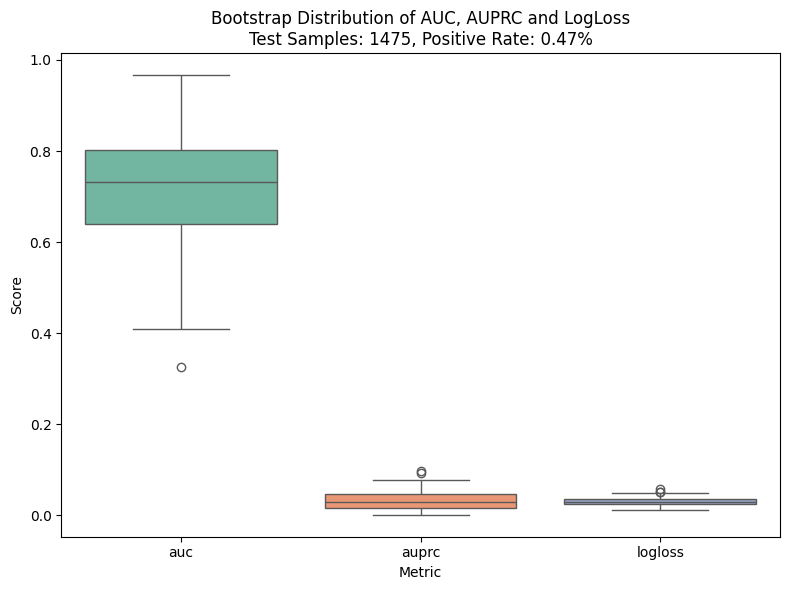

In [151]:
# ✅ 加载模型
final_model_path = '/content/saved_models_xgboost_single/best_xgboost_1_final.model'
model = xgb.Booster()
model.load_model(final_model_path)

# ✅ 创建 DMatrix 测试集
dtest = xgb.DMatrix(X_target_test)

# ✅ 预测概率
test_preds_proba = model.predict(dtest)

# ✅ 评估指标
test_auc = roc_auc_score(y_target_test, test_preds_proba)
test_auprc = average_precision_score(y_target_test, test_preds_proba)

print(f"🎯 测试集 AUC: {test_auc:.4f}")
print(f"🎯 测试集 AUPRC: {test_auprc:.4f}")

# ✅ Bootstrap 评估
n_bootstrap = 100
aucs, auprcs, loglosses = [], [], []
rng = np.random.default_rng(seed=42)

for _ in range(n_bootstrap):
    indices = rng.choice(len(y_target_test), size=len(y_target_test), replace=True)
    y_true_boot = y_target_test[indices]
    y_pred_boot = test_preds_proba[indices]

    if len(np.unique(y_true_boot)) < 2:
        continue

    aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
    auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
    loglosses.append(log_loss(y_true_boot, y_pred_boot))

auc_ci = np.percentile(aucs, [2.5, 97.5])
auprc_ci = np.percentile(auprcs, [2.5, 97.5])
logloss_ci = np.percentile(loglosses, [2.5, 97.5])

print(f"✅ 测试集 AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
print(f"✅ 测试集 AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
print(f"✅ 测试集 LogLoss: {log_loss(y_target_test, test_preds_proba):.4f} (95% CI: {logloss_ci[0]:.4f} - {logloss_ci[1]:.4f})")

# ✅ 保存 bootstrap 结果
bootstrap_df = pd.DataFrame({
    'auc': aucs,
    'auprc': auprcs,
    'logloss': loglosses
})

!mkdir -p boots_output
csv_path = '/content/boots_output/all-test-1.csv'
bootstrap_df.to_csv(csv_path, index=False)
print(f"📁 bootstrap结果已保存: {csv_path}")

# ✅ SHAP 计算
shap_values = model.predict(dtest, pred_contribs=True)
shap_df = pd.DataFrame(shap_values, columns=list(X_target_test.columns) + ['bias'])

shap_csv_path = '/content/boots_output/shap_values_all-test-1.csv'
shap_df.to_csv(shap_csv_path, index=False)
print(f"📁 SHAP值已保存: {shap_csv_path}")

# ✅ train SHAP calculation
dtrain = xgb.DMatrix(X_target_train)
shap_values_train = model.predict(dtrain, pred_contribs=True)
shap_train_df = pd.DataFrame(shap_values_train, columns=list(X_target_train.columns) + ['bias'])

shap_train_csv_path = '/content/boots_output/shap_values_all-train-1.csv'
shap_train_df.to_csv(shap_train_csv_path, index=False)
print(f"📁 SHAP训练集值已保存: {shap_train_csv_path}")

# ✅ 统计信息
n_samples = len(y_target_test)
positive_rate = y_target_test.sum() / n_samples

# ✅ Boxplot 图
bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 6))
sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
plt.title(f'Bootstrap Distribution of AUC, AUPRC and LogLoss\n'
          f'Test Samples: {n_samples}, Positive Rate: {positive_rate:.2%}')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

# Cluster

In [152]:
!mkdir model_1

In [153]:
!mv /content/saved_models_xgboost_single/best_xgboost_1_final.model /content/model_1/best_xgboost_1_final.model

In [154]:
!rm -r /content/saved_models_xgboost_single

In [155]:
!rm -r cluster_1

rm: cannot remove 'cluster_1': No such file or directory


In [158]:
model_path = '/content/model_1/best_xgboost_1_final.model'
hospital_id = 1

run_shap_umap_hdbscan_analysis(7, model_path, hospital_id)

计算训练集 SHAP 值...
训练集 UMAP 降维...
训练集 HDBSCAN 聚类...
计算验证集 SHAP 值及映射...
计算 train 集合的各簇指标...
train 集合聚类指标保存至：/content/cluster_1/1_7/cluster_metrics_summary_train.csv
✅ SHAP + UMAP + HDBSCAN 聚类分析完成，结果保存在： /content/cluster_1/1_7


# train-all-cluster-performance

In [159]:
evaluate_all_cluster_combinations(
    cluster_csv_path='/content/cluster_1/1_7/sample_cluster_assignments_combined.csv',
    X_target_test=X_target_test.copy(),
    y_target_test=y_target_test,
    model_path='/content/model_1/best_xgboost_1_final.model',
    clusters_to_include=[-1,0,1,2],
    min_comb_size=1,
    max_comb_size=10,
    n_bootstrap=1000,
    output_dir='/content/cluster_combination-1',
    random_seed=42
)

  0%|          | 0/15 [00:00<?, ?it/s]

缺失的 cluster_id 数量: 0
➡️ 组合 [-1]：样本数 19, Positive Rate: 0.00%
⚠️ 该组合仅包含一个类别 (label=0)，跳过评估
缺失的 cluster_id 数量: 0
➡️ 组合 [0]：样本数 285, Positive Rate: 0.35%
🎯 测试集 AUC: 0.3979
🎯 测试集 AUPRC: 0.0058
🎯 测试集 LogLoss: 0.0280
✅ 测试集 AUC: 0.3979 (95% CI: 0.3380 - 0.4523)
✅ 测试集 AUPRC: 0.0058 (95% CI: 0.0054 - 0.0227)
✅ 测试集 LogLoss: 0.0280 (95% CI: 0.0272 - 0.1020)


 13%|█▎        | 2/15 [00:11<01:11,  5.54s/it]

缺失的 cluster_id 数量: 0
➡️ 组合 [1]：样本数 28, Positive Rate: 0.00%
⚠️ 该组合仅包含一个类别 (label=0)，跳过评估
缺失的 cluster_id 数量: 0
➡️ 组合 [2]：样本数 1143, Positive Rate: 0.52%
🎯 测试集 AUC: 0.7668
🎯 测试集 AUPRC: 0.0320
🎯 测试集 LogLoss: 0.0311
✅ 测试集 AUC: 0.7668 (95% CI: 0.5340 - 0.9634)
✅ 测试集 AUPRC: 0.0320 (95% CI: 0.0069 - 0.1161)
✅ 测试集 LogLoss: 0.0311 (95% CI: 0.0132 - 0.0533)


 27%|██▋       | 4/15 [00:26<01:13,  6.71s/it]

...

缺失的 cluster_id 数量: 0
➡️ 组合 [0, 1, 2]：样本数 1456, Positive Rate: 0.48%
🎯 测试集 AUC: 0.7074
🎯 测试集 AUPRC: 0.0233
🎯 测试集 LogLoss: 0.0302
✅ 测试集 AUC: 0.7074 (95% CI: 0.4642 - 0.9252)
✅ 测试集 AUPRC: 0.0233 (95% CI: 0.0045 - 0.0962)
✅ 测试集 LogLoss: 0.0302 (95% CI: 0.0140 - 0.0522)


 93%|█████████▎| 14/15 [01:39<00:09,  9.39s/it]

缺失的 cluster_id 数量: 0
➡️ 组合 [-1, 0, 1, 2]：样本数 1475, Positive Rate: 0.47%
🎯 测试集 AUC: 0.7076
🎯 测试集 AUPRC: 0.0233
🎯 测试集 LogLoss: 0.0299
✅ 测试集 AUC: 0.7076 (95% CI: 0.4671 - 0.9379)
✅ 测试集 AUPRC: 0.0233 (95% CI: 0.0043 - 0.0791)
✅ 测试集 LogLoss: 0.0299 (95% CI: 0.0135 - 0.0488)


100%|██████████| 15/15 [01:49<00:00,  7.31s/it]

✅ 所有评估完成。结果保存在 /content/cluster_combination-1


# cluster performance

In [160]:
y_train = pd.Series(y_train, index=X_train.index)
y_target_test = pd.Series(y_target_test, index=X_test.index)

In [161]:
retrain_and_evaluate_all_cluster_combinations(
    cluster_csv_path='/content/cluster_1/1_7/sample_cluster_assignments_combined.csv',
    X_train=X_train,
    y_train=y_train,
    X_test=X_target_test,
    y_test=y_target_test,
    clusters_to_include=[-1,0, 1, 2],
    min_comb_size=1,
    max_comb_size=10,   # ⚠️ 建议先小一点
    n_bootstrap=1000,
    output_dir='/content/cluster_combination_retrain_1',
    random_seed=42
)

Cluster combinations:   0%|          | 0/15 [00:00<?, ?it/s]


🚀 Cluster 组合重新训练: -1
组合 (-1,) 原始 keep_ids 数量: 55
与 X.index 交集后数量: 55
组合 (-1,) 原始 keep_ids 数量: 19
与 X.index 交集后数量: 19
❌ Cluster -1 失败: 无正样本

🚀 Cluster 组合重新训练: 0
组合 (0,) 原始 keep_ids 数量: 631
与 X.index 交集后数量: 631
组合 (0,) 原始 keep_ids 数量: 285
与 X.index 交集后数量: 285
❌ Cluster 0 失败: 无正样本

🚀 Cluster 组合重新训练: 1
组合 (1,) 原始 keep_ids 数量: 64
与 X.index 交集后数量: 64
组合 (1,) 原始 keep_ids 数量: 28
与 X.index 交集后数量: 28
❌ Cluster 1 失败: 无正样本

🚀 Cluster 组合重新训练: 2
组合 (2,) 原始 keep_ids 数量: 2690
与 X.index 交集后数量: 2690
组合 (2,) 原始 keep_ids 数量: 1143
与 X.index 交集后数量: 1143
❌ Cluster 2 失败: 无正样本

🚀 Cluster 组合重新训练: -1_0
组合 (-1, 0) 原始 keep_ids 数量: 686
与 X.index 交集后数量: 686
组合 (-1, 0) 原始 keep_ids 数量: 304
与 X.index 交集后数量: 304
【XGBOOST】单次训练验证开始 - 2025-12-27 14:48:47
✅ 模型输出路径: saved_models_xgboost_single/best_xgboost_19_cluster_-1_0.model

🏗️ 训练xgboost模型中...
[0]	train-aucpr:0.43277	train-logloss:0.68401	eval-aucpr:0.16371	eval-logloss:0.68470
[20]	train-aucpr:1.00000	train-logloss:0.53539	eval-aucpr:0.48014	eval-logloss:0.54572
[40]	t


Bootstrap评估: 100%|██████████| 1000/1000 [00:05<00:00, 179.85it/s]



🎯 最终评估结果:
AUROC: 0.9776 (95% CI: 0.9514 - 0.9981)
AUPRC: 0.4571 (95% CI: 0.2909 - 0.9500)
Accuracy: 0.9565

🔁 使用 train + val 合并数据进行最终训练...
✅ 最终模型已保存: saved_models_xgboost_single/best_xgboost_19_cluster_-1_0_final.model
AUC: 0.3366 (95% CI: 0.2871-0.3861), p=1.0000
AUPRC: 0.0050 (95% CI: 0.0047-0.0199), p=0.0000
LogLoss: 0.0402 (95% CI: 0.0319-0.0947), p=0.0031


Cluster combinations:  33%|███▎      | 5/15 [00:13<00:27,  2.79s/it]

...


🚀 Cluster 组合重新训练: 0_1_2
组合 (0, 1, 2) 原始 keep_ids 数量: 3385
与 X.index 交集后数量: 3385
组合 (0, 1, 2) 原始 keep_ids 数量: 1456
与 X.index 交集后数量: 1456
❌ Cluster 0_1_2 失败: 无正样本

🚀 Cluster 组合重新训练: -1_0_1_2
组合 (-1, 0, 1, 2) 原始 keep_ids 数量: 3440
与 X.index 交集后数量: 3440
组合 (-1, 0, 1, 2) 原始 keep_ids 数量: 1475
与 X.index 交集后数量: 1475
【XGBOOST】单次训练验证开始 - 2025-12-27 14:50:17
✅ 模型输出路径: saved_models_xgboost_single/best_xgboost_19_cluster_-1_0_1_2.model

🏗️ 训练xgboost模型中...
[0]	train-aucpr:0.02180	train-logloss:0.68692	eval-aucpr:0.00389	eval-logloss:0.68756
[20]	train-aucpr:0.50056	train-logloss:0.57077	eval-aucpr:0.00393	eval-logloss:0.57841
[40]	train-aucpr:0.84940	train-logloss:0.47570	eval-aucpr:0.00420	eval-logloss:0.48783
[60]	train-aucpr:0.96199	train-logloss:0.40064	eval-aucpr:0.00392	eval-logloss:0.41609
[80]	train-aucpr:0.98882	train-logloss:0.33848	eval-aucpr:0.00400	eval-logloss:0.35685
[100]	train-aucpr:0.99218	train-logloss:0.28984	eval-aucpr:0.00400	eval-logloss:0.31001
[120]	train-aucpr:0.99621	train


Bootstrap评估: 100%|██████████| 1000/1000 [00:06<00:00, 146.22it/s]



🎯 最终评估结果:
AUROC: 0.4744 (95% CI: 0.2769 - 0.6407)
AUPRC: 0.0066 (95% CI: 0.0058 - 0.0130)
Accuracy: 0.9927

🔁 使用 train + val 合并数据进行最终训练...
✅ 最终模型已保存: saved_models_xgboost_single/best_xgboost_19_cluster_-1_0_1_2_final.model
AUC: 0.7076 (95% CI: 0.4671-0.9379), p=0.0470
AUPRC: 0.0233 (95% CI: 0.0043-0.0791), p=0.0280
LogLoss: 0.0299 (95% CI: 0.0135-0.0488), p=0.0000


Cluster combinations: 100%|██████████| 15/15 [01:55<00:00,  7.69s/it]


✅ 所有 cluster 组合重新训练完成，结果已保存至 /content/cluster_combination_retrain_1


In [162]:
!zip -r mimic-iv.zip /content/* -x /content/mimic_pulseOx_data.csv

  adding: content/bold_dataset.csv (deflated 67%)
  adding: content/boots_output/ (stored 0%)
  adding: content/boots_output/shap_values_all-train-1.csv (deflated 61%)
  adding: content/boots_output/shap_values_all-test-1.csv (deflated 61%)
  adding: content/boots_output/all-test-1.csv (deflated 52%)
  adding: content/cluster_1/ (stored 0%)
  adding: content/cluster_1/1_7/ (stored 0%)
  adding: content/cluster_1/1_7/cluster_metrics_summary_train.csv (deflated 65%)
  adding: content/cluster_1/1_7/umap_hdbscan_clusters_train.png (deflated 4%)
  adding: content/cluster_1/1_7/cluster_true_distribution_train.png (deflated 30%)
  adding: content/cluster_1/1_7/sample_cluster_assignments_combined.csv (deflated 77%)
  adding: content/cluster_combination-1/ (stored 0%)
  adding: content/cluster_combination-1/cluster_-1_0_2_results_shap.csv (deflated 60%)
  adding: content/cluster_combination-1/cluster_-1_2_results.csv (deflated 56%)
  adding: content/cluster_combination-1/cluster_0_2_results_sha